In [1]:
# 载入 PyTomoATT 模块
# 文档：https://tomoatt.github.io/PyTomoATT/index.html

import pytomoatt as pta
from pytomoatt.model import ATTModel

import numpy as np

In [2]:
# 载入 PyGMT 模块
import pygmt
pygmt.config(FONT="16p")
pygmt.config(IO_SEGMENT_MARKER="<<<")

In [ ]:
# 文件名称
par_file         = "3_input_params/input_params_step3_inv_reloc.yaml"          # parameter file

# 迭代10次反演结果
model_file   = "OUTPUT_FILES/OUTPUT_FILES_step3_inv_reloc/final_model.h5"       # checkerboard model file
output_fname     = "Step5_real_inv.png"

# 完整100次迭代结果
# model_file   = "benchmark_dataset/OUTPUT_FILES_step3_inv_reloc_100iter/final_model.h5"       # checkerboard model file
# output_fname     = "Step5_real_inv_100iter.png"

In [5]:
# 旋转参数
theta0_rotate  =   37.0    # 旋转中心纬度
phi0_rotate    =   37.0    # 旋转中心经度
psi_rotate     =   45      # 顺时针旋转角度
rotate_params = [theta0_rotate, phi0_rotate, psi_rotate]

# 指定深度
all_dep = [5,10,15]


# ------------ PyGMT 绘图参数 ------------
# projection should be "psi_rotate+90", 使正北方向仍然指向北方向
projection_angle = psi_rotate + 90
projection = "OA%f/%f/%f/5c"%(theta0_rotate,phi0_rotate,projection_angle)  # 投影方式。注意，选择投影方式是，需要确保各向异性箭头方向和实际方向一致。
perspective = "135/90"  # 视角

region = "-1.5/1.5/-2.5/3.5",
region_large = [33,42,34,42]
xshift      = [ 3,  8.5, 8.5, 8.5, ]
yshift      = [ 80, 0,  0,  0, 0]
xshift_ani  = [ -17,  8.5, 8.5, 8.5, ]
yshift_ani  = [ -10, 0,  0,  0, ]

frame = [
    ["xa2g2","ya2g2","NsWe"],["xa2g2","ya2g2","Nswe"],
    ["xa2g2","ya2g2","NswE"],
]
frame_ani = [
    ["xa2g2","ya2g2","NSWe"],["xa2g2","ya2g2","NSwe"],
    ["xa2g2","ya2g2","NSwE"],
]

vel_per     = 5     # velocity perturbation colorbar range
ani_per     = 0.05  # anisotropy colorbar length
ani_per_1   = 0.015; ani_per_2 = 0.05 # anisotropy bar length [ani_per_1,ani_per_2] -> [0.1,0.6] (ani -> length)

subfigure = ['(a)', '(b)','(c)']
subfigure_ani = ['(d)', '(e)','(f)']

In [6]:
# 读取模型

model_inv = ATTModel.read(model_file,par_file)
# model_ini = ATTModel.read(fname_ini,input_file)

# get anisotropy model
model_inv.to_ani()

bm_inv = model_inv.to_xarray()

n_rtp = bm_inv.vel.shape

# 速度结构画图

In [7]:
fig = pygmt.Figure()

for i in range(0,len(all_dep)):
# for i in range(0,1):
    print('plotting: dep %3d'%(all_dep[i]))

    # 计算区域是 [-1.5, 1.5, -2.5, 3.5]，为了将坐标返回到物理坐标系，需要进行旋转，需要添加 rotate = rotate_params。
    # 如果不涉及到旋转，则不需要添加 rotate = rotate_params。
    x_phy         = bm_inv.interp_dep(all_dep[i],"vel", rotate = rotate_params)[:,0]
    y_phy         = bm_inv.interp_dep(all_dep[i],"vel", rotate = rotate_params)[:,1]
    
    # average velocity as reference model
    ref_model = np.mean(bm_inv.interp_dep(all_dep[i],"vel", rotate = rotate_params)[:,2])

    pert        = bm_inv.interp_dep(all_dep[i],"vel", rotate = rotate_params)[:,2]
    pert        = (pert - ref_model)/ref_model * 100
    
    grid    = pygmt.surface(x=x_phy, y=y_phy, z=pert, spacing="01m", region=region_large)
   
    # ----------- basemap ----------------
    fig.shift_origin(xshift=xshift[i],yshift = yshift[i])
    fig.basemap(frame=frame[i], projection=projection, region=region, perspective = perspective)


    # ----------- colorbar ---------------- 
    pygmt.makecpt(cmap="./utils/svel13_chen.cpt", series=[-vel_per, vel_per], background = True)

    # ----------- velocity perturbation map ----------------
    fig.grdimage(frame=frame[i],grid = grid,projection=projection, region=region, perspective = perspective,transparency=30)
    
    # ----------- linement ----------------
    fig.plot("./utils/tectonics/eshm20_new.txt", pen = '1p,gray38',perspective = perspective,)


    # ----------- coast ----------------
    fig.coast(shorelines="0.5p,black",perspective = perspective,)


    # rupture segments
    fig.plot("./utils/tectonics/NPF_rupture_region.txt", pen = '5p,white',perspective=perspective,transparency = 0)
    fig.plot("./utils/tectonics/EAF_rupture_region_Song1.txt", pen = '5p,white',perspective=perspective,transparency = 0)   # Seg.A 走滑 正 
    fig.plot("./utils/tectonics/EAF_rupture_region_Song2.txt", pen = '5p,white',perspective=perspective,transparency = 0) # Seg P 走滑
    fig.plot("./utils/tectonics/EAF_rupture_region_Song3.txt", pen = '5p,white',perspective=perspective,transparency = 0)   # Seg.E 走滑 逆冲
    
    fault_color = ["magenta","blue","purple"]
    fig.plot("./utils/tectonics/NPF_rupture_region.txt", pen = '3p,%s'%(fault_color[1]),perspective=perspective,transparency = 0)
    fig.plot("./utils/tectonics/EAF_rupture_region_Song1.txt", pen = '3p,%s'%(fault_color[0]),perspective=perspective,transparency = 0)   # Seg.A 走滑 正 
    fig.plot("./utils/tectonics/EAF_rupture_region_Song2.txt", pen = '3p,%s'%(fault_color[1]),perspective=perspective,transparency = 0) # Seg P 走滑
    fig.plot("./utils/tectonics/EAF_rupture_region_Song3.txt", pen = '3p,%s'%(fault_color[2]),perspective=perspective,transparency = 0)   # Seg.E 走滑 逆冲


    # ----------- major earthquakes ----------------
    fig.plot(x = [37.206], y = [38.016], style = "a", fill = "green3", size = [0.5],pen = '1p,black',perspective = perspective)
    fig.plot(x = [37.019], y = [37.220], style = "a", fill = "red", size = [0.8],pen = '1.5p,white',perspective = perspective)
    fig.plot(x = [39.061], y = [38.431], style = "a", fill = "blue", size = [0.6],pen = '1p,white',perspective = perspective)  #USGS


    # ----------- notations ----------------
    fig.shift_origin(xshift = 0.4,yshift = 0)
    fig.basemap( frame=["NSEW+gwhite"], projection="X5/2", region=[0,1,0,1],)
    fig.text(text="Vp  = %4.2f km/s"%(ref_model), x=0.5, y=0.75, font="18p,Helvetica-Bold,black", fill="white")
    fig.text(text="Depth = %3d km"%(all_dep[i]), x=0.5, y=0.25, font="18p,Helvetica-Bold,black", fill="white")
    fig.shift_origin(xshift =-0.4,yshift = 0)


plotting: dep   5
plotting: dep  10
plotting: dep  15


# 各向异性画图

plotting: dep   5
plotting: dep  10
plotting: dep  15


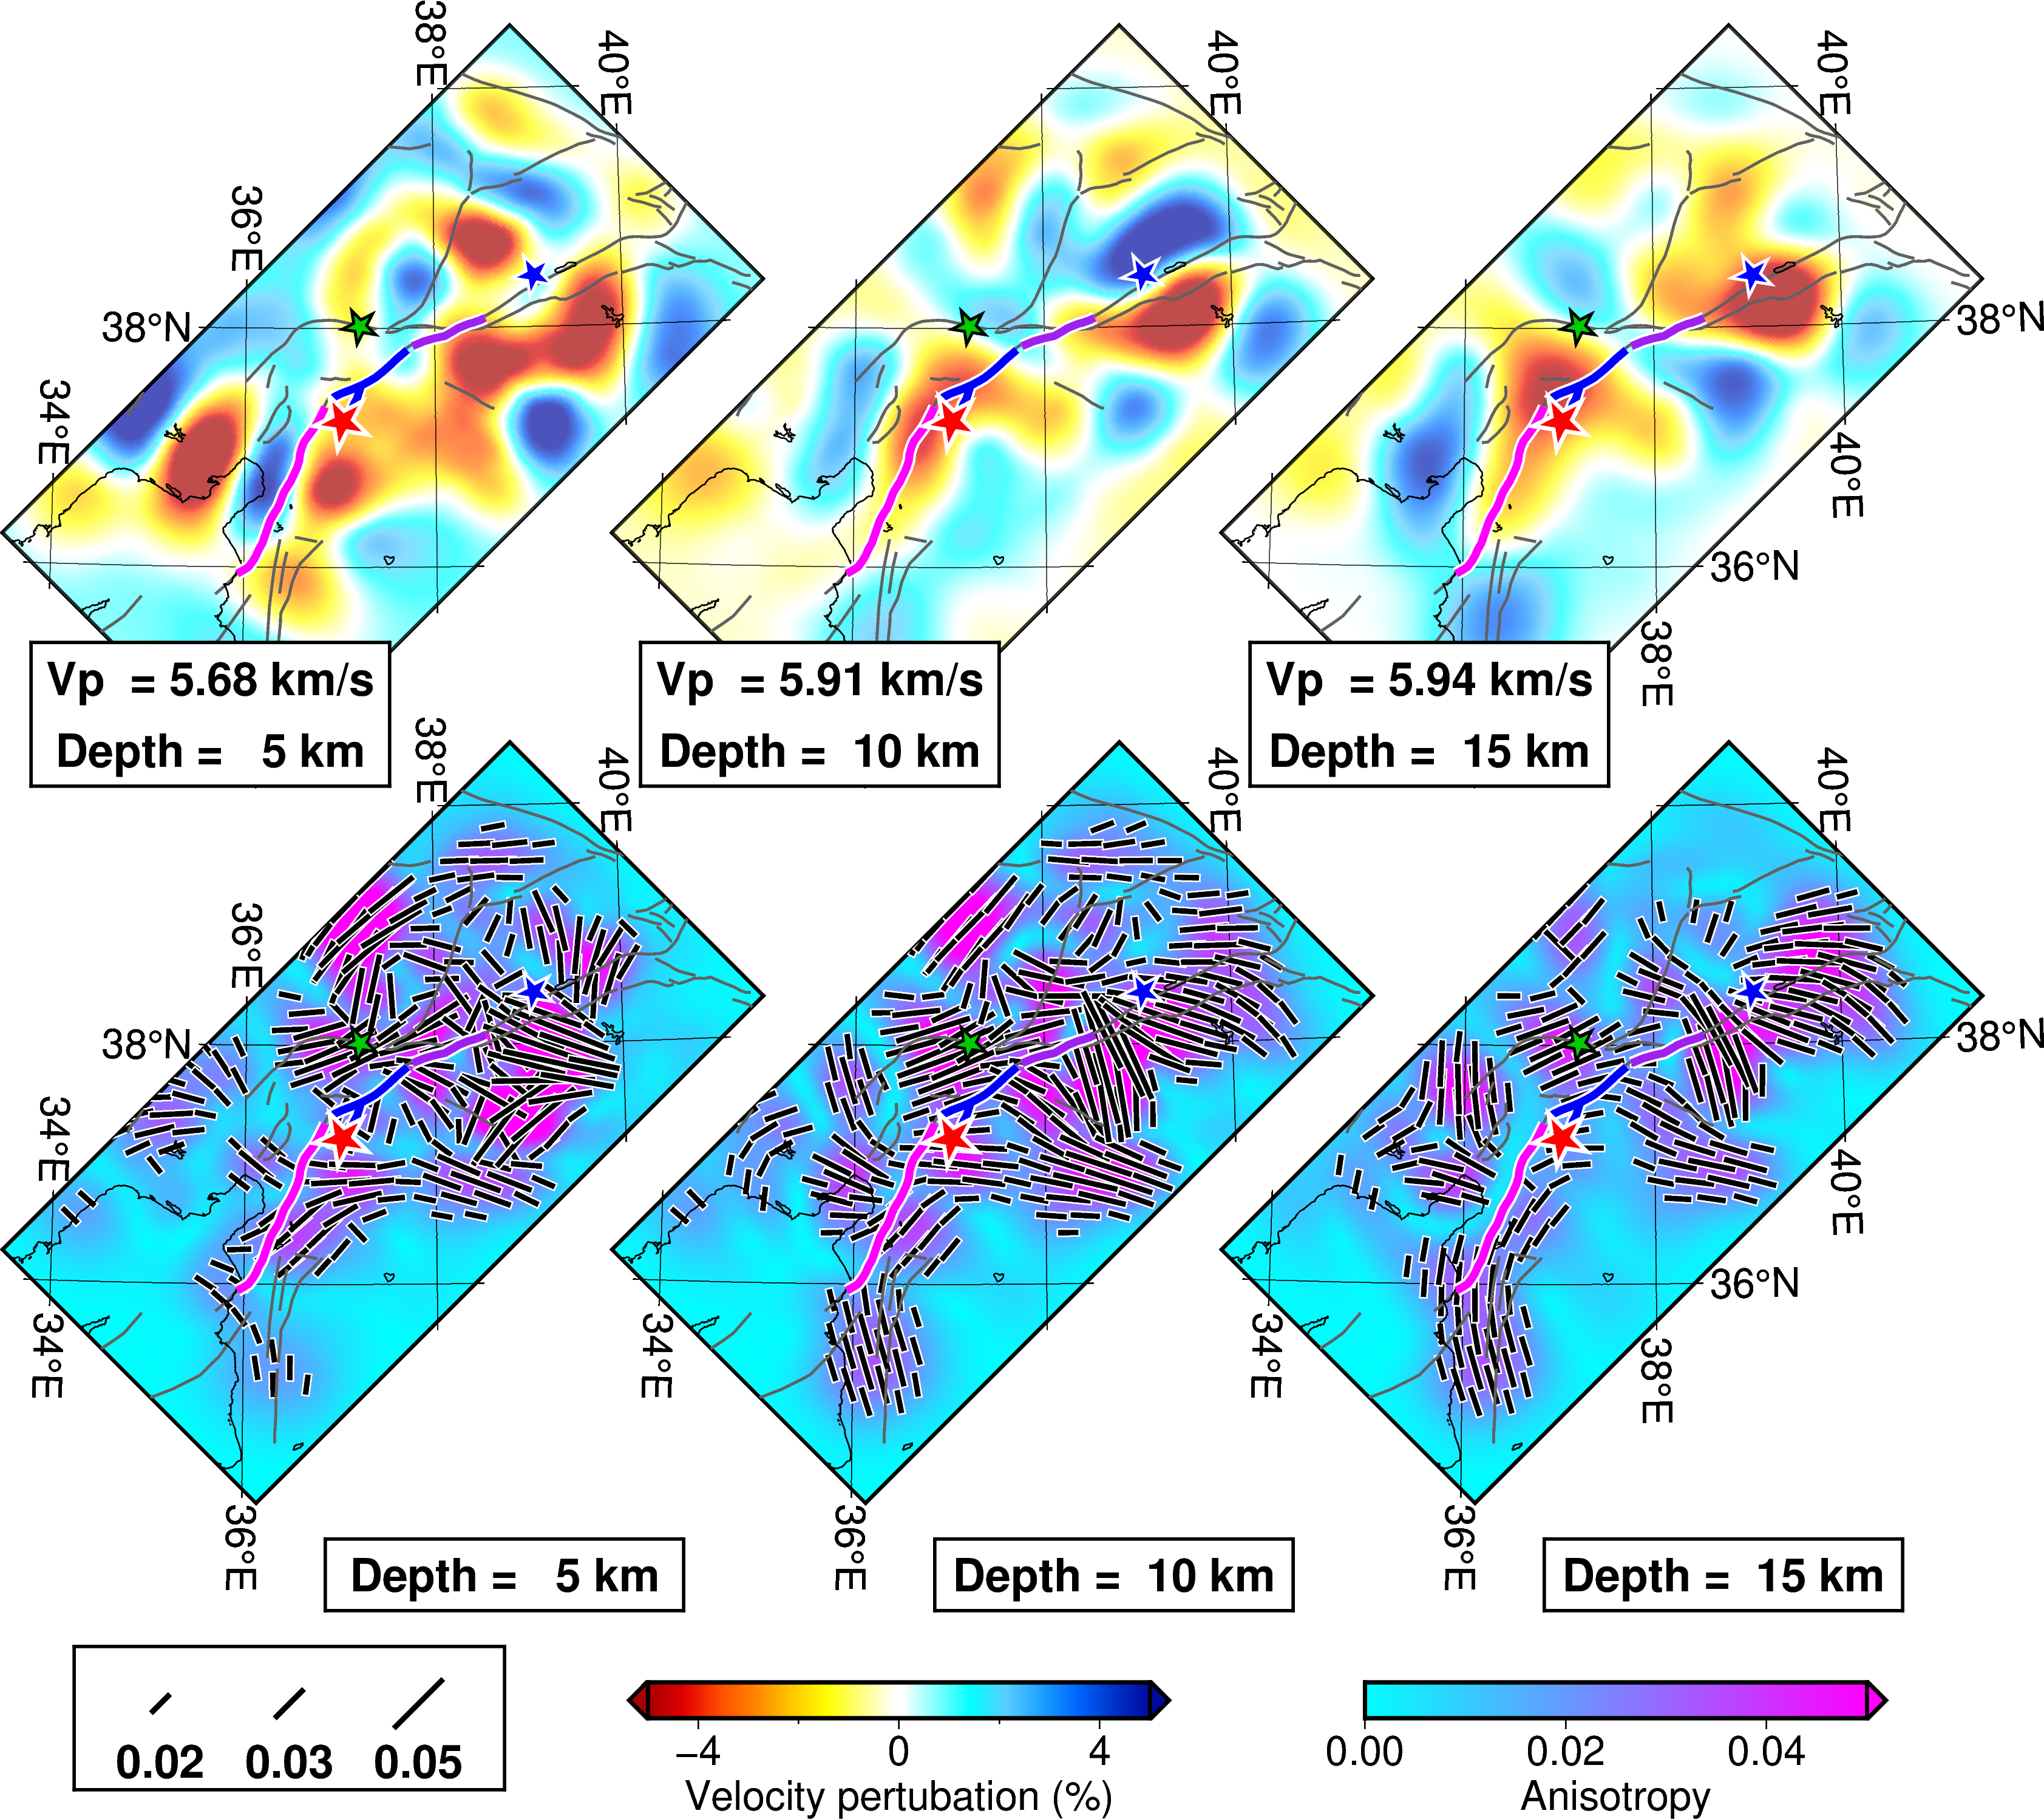

In [8]:
def ani_to_length(ani, ani_per_1, ani_per_2, scale, basic):
    return (ani - ani_per_1) / (ani_per_2 - ani_per_1) * scale + basic


for i in range(0,len(all_dep)):
    print('plotting: dep %3d'%(all_dep[i]))
    
    # anisotropy map
    x_phy         = bm_inv.interp_dep(all_dep[i],"vel", rotate=rotate_params)[:,0]
    y_phy         = bm_inv.interp_dep(all_dep[i],"vel", rotate=rotate_params)[:,1]
    epsilon       = bm_inv.interp_dep(all_dep[i],"epsilon", rotate=rotate_params)[:,2]

    grid = pygmt.surface(x=x_phy, y=y_phy, z=epsilon, spacing="01m", region=region_large)

    # fast velocity direction bars
    samp_interval = [(n_rtp[0]-1)//12, (n_rtp[0]-1)//12]
    width = 0.1
    scale = 0.7
    basic = 0.3
    ani_thd = ani_per_1

    # 各向异性快轴角度，参考计算区域东方向，逆时针角度
    # rotate=rotate_params, 则输出角度变已经进行了旋转补偿，此时输出角度是在物理坐标系中的角度，参考现实东方向，逆时针角度
    phi         = bm_inv.interp_dep(all_dep[i], field='phi', samp_interval=samp_interval, rotate=rotate_params)          # phi_inv[i,:] are (lon, lat, phi)
    # 各向异性强度
    epsilon     = bm_inv.interp_dep(all_dep[i], field='epsilon', samp_interval=samp_interval, rotate=rotate_params)      # epsilon_inv[i,:] are (lon, lat, epsilon)
    ani_lon     = phi[:,0].reshape(-1,1)
    ani_lat     = phi[:,1].reshape(-1,1)
    ani_phi     = phi[:,2].reshape(-1,1)
    ani_epsilon = epsilon[:,2].reshape(-1,1)

    # # 旋转补偿：ani_phi 表示参考计算区域东方向，逆时针角度。由于实际区域相对于计算区域，进行了顺时针旋转 psi_rotate 角度。因此各向异性角度需要补偿 - psi_rotate
    # rotate_compensation = - psi_rotate # 如果没有旋转可以不需要补偿
    # 投影补偿：画图的projection="OA%f/%f/%f/5c"%(theta0_rotate,phi0_rotate,projection_angle) 会旋转画图区域，但是不改变箭头方向。因此需要补偿角度 (projection_angle - 90)
    projection_compensation = (projection_angle - 90)
    # ani_phi     = ani_phi + rotate_compensation + projection_compensation   # 对角度做修正。
    ani_phi    = ani_phi + projection_compensation   # 对角度做修正。

    length          = ani_to_length(ani_epsilon, ani_per_1, ani_per_2, scale, basic)
    ani_arrow_full  = np.hstack([ani_lon, ani_lat, ani_phi, length, np.ones((ani_lon.size,1))*width])   # lon, lat, angle[-90,90], length, width

    # remove arrows with small amplitude of anisotropy
    idx = np.where((ani_epsilon > ani_thd))
    ani_arrow       = ani_arrow_full[idx[0],:]

    # ----------- colorbar ---------------- 
    pygmt.makecpt(cmap="cool", series=[0, ani_per],background=True)


    # ----------- basemap ----------------
    fig.shift_origin(xshift=xshift_ani[i],yshift = yshift_ani[i])
    fig.basemap(frame=frame_ani[i], projection=projection, region=region, perspective = perspective)

    # ----------- anisotropy map ----------------
    fig.grdimage(frame=frame_ani[i],grid = grid,projection=projection,region=region,perspective = perspective,)

    # fast velocity direction bars
    fig.plot(ani_arrow, style = "j", pen = "0.5p,white",fill="black",perspective = perspective)

    # ----------- linement ----------------    
    fig.plot("./utils/tectonics/eshm20_new.txt", pen = '1p,gray38',perspective = perspective,)

    # ----------- coastlines ----------------
    fig.coast(shorelines="0.5p,black",perspective = perspective,)
    
    # rupture segments
    fig.plot("./utils/tectonics/NPF_rupture_region.txt", pen = '5p,white',perspective=perspective,transparency = 0)
    fig.plot("./utils/tectonics/EAF_rupture_region_Song1.txt", pen = '5p,white',perspective=perspective,transparency = 0)   # Seg.A 
    fig.plot("./utils/tectonics/EAF_rupture_region_Song2.txt", pen = '5p,white',perspective=perspective,transparency = 0) # Seg P
    fig.plot("./utils/tectonics/EAF_rupture_region_Song3.txt", pen = '5p,white',perspective=perspective,transparency = 0)   # Seg.E 

    fault_color = ["magenta","blue","purple"]
    fig.plot("./utils/tectonics/NPF_rupture_region.txt", pen = '3p,%s'%(fault_color[1]),perspective=perspective,transparency = 0)
    fig.plot("./utils/tectonics/EAF_rupture_region_Song1.txt", pen = '3p,%s'%(fault_color[0]),perspective=perspective,transparency = 0)   # Seg.A
    fig.plot("./utils/tectonics/EAF_rupture_region_Song2.txt", pen = '3p,%s'%(fault_color[1]),perspective=perspective,transparency = 0) # Seg P
    fig.plot("./utils/tectonics/EAF_rupture_region_Song3.txt", pen = '3p,%s'%(fault_color[2]),perspective=perspective,transparency = 0)   # Seg.E 


    # ----------- major earthquakes ----------------
    fig.plot(x = [37.206], y = [38.016], style = "a", fill = "green3", size = [0.5],pen = '1p,black',perspective = perspective)
    fig.plot(x = [37.019], y = [37.220], style = "a", fill = "red", size = [0.8],pen = '1.5p,white',perspective = perspective)
    fig.plot(x = [39.061], y = [38.431], style = "a", fill = "blue", size = [0.6],pen = '1p,white',perspective = perspective)  #USGS
    

    # ----------- notations ----------------
    fig.shift_origin(xshift = 4.5,yshift = -1.5)
    fig.basemap( frame=["NSEW"], projection="X5/1", region=[0,1,0,1],)
    fig.text(text="Depth = %3d km"%(all_dep[i]), x=0.5, y=0.5, font="18p,Helvetica-Bold,black", fill="white")
    fig.shift_origin(xshift =-4.5,yshift = 1.5)

# ----------- colorbars ----------------
pygmt.makecpt(cmap="cool", series=[0, ani_per],background=True)
fig.shift_origin(xshift=2,yshift = -3)
fig.colorbar(frame = ["a0.02","x+lAnisotropy"], position="+ef+w7c/0.5c+h") 

pygmt.makecpt(cmap="./utils/svel13_chen.cpt", series=[-vel_per, vel_per], background = True)
fig.shift_origin(xshift = -10, yshift = 0)
fig.colorbar(frame = ["a4f2","x+lVelocity pertubation (%)"], position="+e+w7c/0.5c+h", ) 

fig.shift_origin(xshift =  -8,yshift = -1)
fig.basemap(frame=["NSEW"],projection="X6/2", region=[0,1,0,1])

length = ani_to_length(0.02, ani_per_1, ani_per_2, 0.7, 0.3)
fig.plot(x = 0.2, y = 0.6, style = "j45/%f/0.1"%(length), pen = "0.5p,white",fill="black")
fig.text(text="0.02", x=0.2, y=0.2, font="18p,Helvetica-Bold,black")

length = ani_to_length(0.03, ani_per_1, ani_per_2, 0.7, 0.3)
fig.plot(x = 0.5, y = 0.6, style = "j45/%f/0.1"%(length), pen = "0.5p,white",fill="black")
fig.text(text="0.03", x=0.5, y=0.2, font="18p,Helvetica-Bold,black")

length = ani_to_length(0.05, ani_per_1, ani_per_2, 0.7, 0.3)
fig.plot(x = 0.8, y = 0.6, style = "j45/%f/0.1"%(length), pen = "0.5p,white",fill="black")
fig.text(text="0.05", x=0.8, y=0.2, font="18p,Helvetica-Bold,black")

import os
os.makedirs('./figs', exist_ok=True)
fig.savefig(f'./figs/{output_fname}')

fig.show()

# 垂向剖面速度

In [9]:
# 剖面位置
start_point_phy = [39, 39]
end_point_phy   = [40, 38]

In [10]:
# （可选）可以通过旋转，相互转换 物理坐标系（实际空间） 与 计算坐标系（TomoATT内部计算）
from pytomoatt.utils.rotate import rtp_rotation, rtp_rotation_reverse

# 物理坐标系（实际空间） -> 计算坐标系（TomoATT内部计算）
start_point_cal = np.zeros(2)
end_point_cal   = np.zeros(2)
start_point_cal[1], start_point_cal[0] = rtp_rotation(start_point_phy[1], start_point_phy[0], theta0_rotate, phi0_rotate, psi_rotate)
end_point_cal[1], end_point_cal[0] = rtp_rotation(end_point_phy[1], end_point_phy[0], theta0_rotate, phi0_rotate, psi_rotate)
print("start_point_cal: ", start_point_cal)
print("end_point_cal: ", end_point_cal)

# 计算坐标系（TomoATT内部计算） -> 物理坐标系（实际空间）
start_point_phy = np.zeros(2)
end_point_phy   = np.zeros(2)
start_point_phy[1], start_point_phy[0] = rtp_rotation_reverse(start_point_cal[1], start_point_cal[0], theta0_rotate, phi0_rotate, psi_rotate)
end_point_phy[1], end_point_phy[0] = rtp_rotation_reverse(end_point_cal[1], end_point_cal[0], theta0_rotate, phi0_rotate, psi_rotate)
print("start_point_phy: ", start_point_phy)
print("end_point_phy: ", end_point_phy)


start_point_cal:  [-0.32696133  2.52511378]
end_point_cal:  [0.93832583 2.40496778]
start_point_phy:  [39. 39.]
end_point_phy:  [40. 38.]


In [11]:
print("start_point_cal: ", start_point_cal)
print("end_point_cal: ", end_point_cal)
print("start_point_phy: ", start_point_phy)
print("end_point_phy: ", end_point_phy)

start_point_cal:  [-0.32696133  2.52511378]
end_point_cal:  [0.93832583 2.40496778]
start_point_phy:  [39. 39.]
end_point_phy:  [40. 38.]


d:\my_software\python\lib\site-packages\pyproj\geod.py:827: UserWarning: Back azimuth is being returned by default to be compatible with inv()This is a breaking change for pyproj 3.5+.To avoid this warning, set return_back_azimuth=True.Otherwise, to restore old behaviour, set return_back_azimuth=False.This warning will be removed in future version.
  warnings.warn(
surface [WARNING]: 1066 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surface [WARNING]: Possibly some data were half-way between nodes and subject to IEEE 754 rounding.


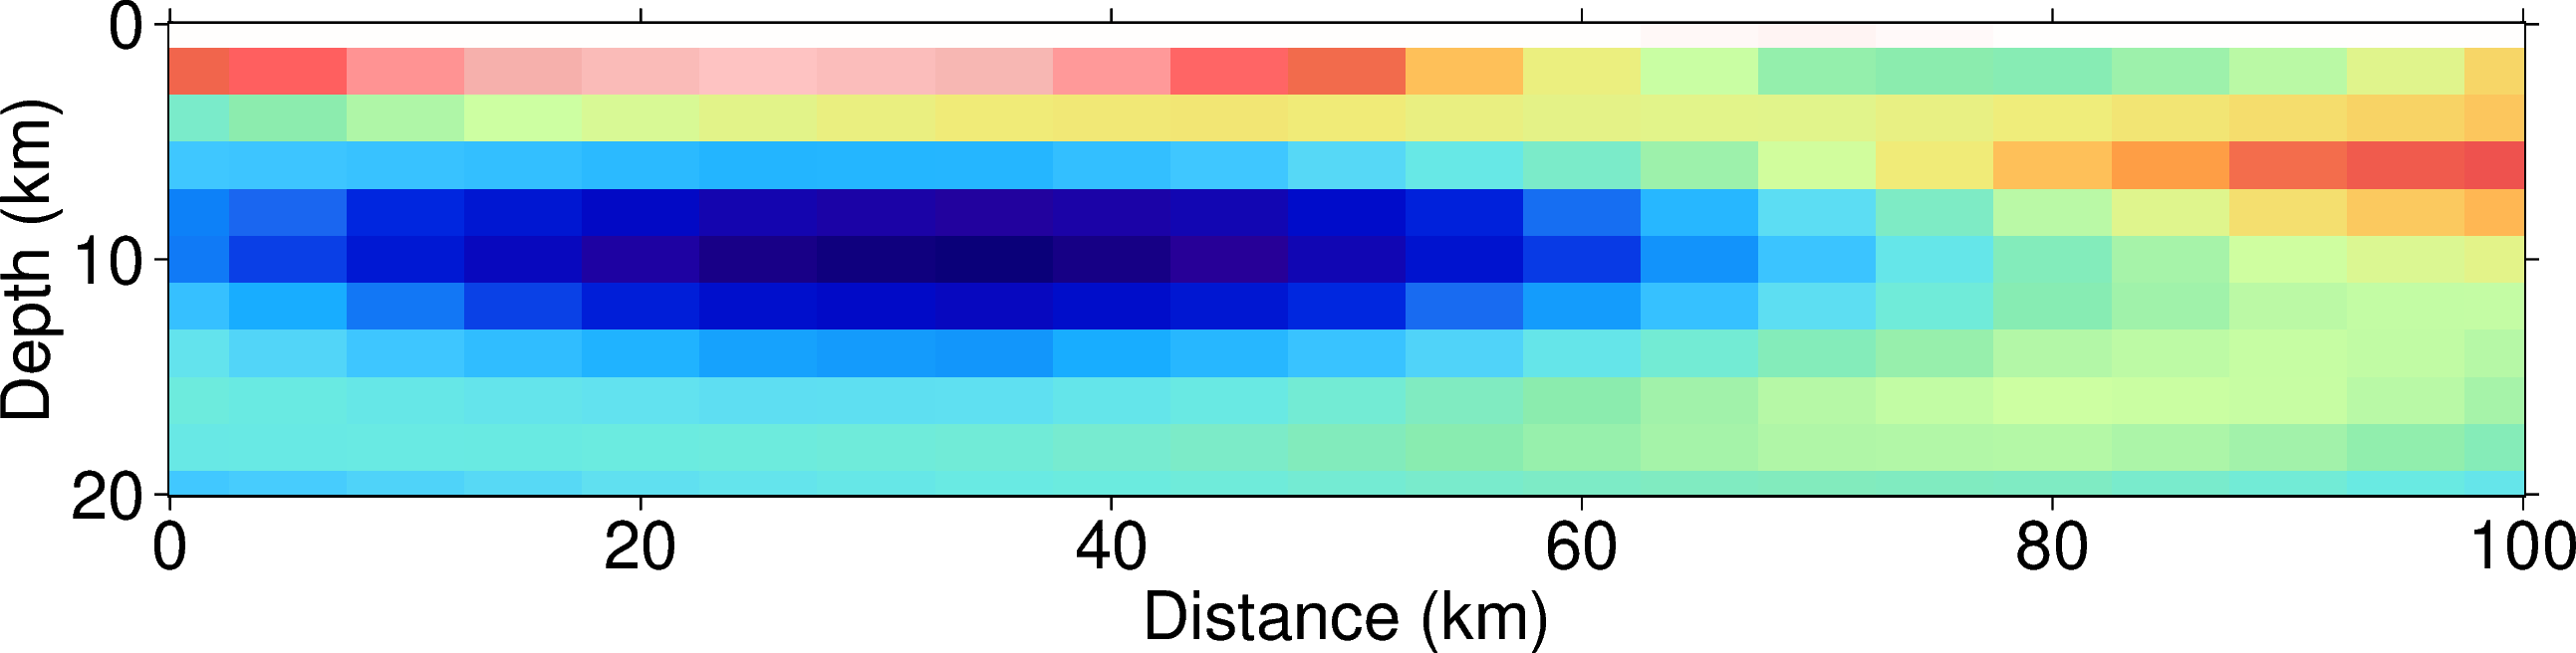

In [12]:
fig = pygmt.Figure()

projection = "X20/-4"
region = [0,100,0,20] # 100 km 长，20 km 深
frame  = ["xa20+lDistance (km)","ya10+lDepth (km)","nSWe"]

# 使用物理坐标系（实际空间）进行剖面插值
# vel_sec = bm_inv.interp_sec(start_point_phy, end_point_phy, val=1, field='vel', rotate=rotate_params, input_type="phy", output_type="phy")

# 或者使用计算坐标系（TomoATT内部计算）进行剖面插值
vel_sec = bm_inv.interp_sec(start_point_cal, end_point_cal, val=1, field='vel', rotate=rotate_params, input_type="cal", output_type="phy")

fig.basemap(frame=frame, projection=projection, region=region)

lon_sec = vel_sec[:,0]
lat_sec = vel_sec[:,1]
dis_sec = vel_sec[:,2]
dep_sec = vel_sec[:,3]
vel_sec = vel_sec[:,4]

grid    = pygmt.surface(x=dis_sec, y=dep_sec, z=vel_sec, spacing="5/2", region=region)

pygmt.makecpt(cmap="haxby", series=[5.0, 6.3], background=True, reverse=True)    # colorbar

fig.grdimage(grid = grid)
    
fig.show()

In [13]:
print(dis_sec)
print(dep_sec)
print(vel_sec)

[  0.   0.   0. ... 141. 141. 141.]
[ 50.  48.  46. ...  -6.  -8. -10.]
[8.00037252 7.98287368 7.95448873 ... 5.07353194 5.11943669 5.15302578]
